<a href="https://colab.research.google.com/github/HfzhImn/2025_Artificial-Intelligence_TI-1B/blob/main/Ujian%20Tengah%20Semester%20Kecerdasan%20Buatan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#UJIAN TENGAH SEMESTER KECERDASAN BUATAN
Nama      : Hafizh Iman Wicaksono

Kelas     : TI-1B

NIM       : 4.33.24.1.10

Tanggal   : 23 Mei 2025


## Analisis Data AirBnB New York City


## Import Library dan Load Dataset

Penjelasan:

Pada bagian ini, Saya mengimpor pustaka-pustaka Python yang digunakan untuk analisis data dan visualisasi, yaitu:

1. pandas untuk manipulasi data

2. numpy untuk kalkulasi numerik

3. matplotlib.pyplot dan seaborn untuk membuat grafik

Selain itu, Saya memuat dataset airbnb.csv ke dalam DataFrame (df).

In [ ]:
# ========================
# 1. IMPORT LIBRARY
# ========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Atur tampilan grafik
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ========================
# 2. LOAD DATASET
# ========================
# Baca file CSV
df = pd.read_csv('airbnb.csv')

# Tampilkan 5 baris pertama
df.head()


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## Eksplorasi Dasar

Penjelasan:

Sesi ini bertujuan untuk memahami struktur dan isi dataset secara umum:

- Melihat jumlah baris dan kolom (df.shape)

- Menampilkan informasi tipe data dan nilai kosong (df.info())

- Statistik deskriptif seperti mean, median, min, max (df.describe())

- Mengecek apakah ada missing values (df.isnull().sum())

In [ ]:
# ========================
# 3. EKSPLORASI DASAR
# ========================

# Ukuran data
print("Ukuran dataset:", df.shape)

# Info kolom
df.info()

# Statistik deskriptif
df.describe(include='all')

# Cek nilai kosong
print("Missing Values:\n", df.isnull().sum())


Ukuran dataset: (48895, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last

## Data Cleaning dan Data Manipulation

Penjelasan:

Di bagian ini, kita membersihkan data dan memanipulasi kolom agar siap untuk dianalisis:

- Menghapus data duplikat (drop_duplicates())

- Mengisi missing value (contohnya reviews_per_month)

- Membuat kolom baru price_category untuk mengelompokkan harga ke dalam kategori seperti "Low", "Medium", dll.

- Menampilkan kondisi before dan after untuk menunjukkan perubahan

In [ ]:
# =====================================
# 4. Data Cleaning & Data Manipulation
# =====================================

# --- BEFORE: Cek jumlah duplikat dan missing values ---
print("Jumlah duplikat sebelum dibersihkan:", df.duplicated().sum())
print("\nMissing values sebelum dibersihkan:\n", df.isnull().sum())

# --- Cleaning: Hapus duplikat ---
df_cleaned = df.drop_duplicates()

# --- Cleaning: Isi missing values pada 'reviews_per_month' dengan 0 ---
df_cleaned['reviews_per_monath'] = df_cleaned['reviews_per_month'].fillna(0)

# --- Manipulasi: Buat kolom kategori harga ---
df_cleaned['price_category'] = pd.cut(
    df_cleaned['price'],
    bins=[0, 100, 200, 500, np.inf],
    labels=['Low', 'Medium', 'High', 'Luxury']
)

# --- AFTER: Tampilkan hasil setelah dibersihkan ---
print("\nJumlah duplikat setelah dibersihkan:", df_cleaned.duplicated().sum())
print("\nMissing values setelah dibersihkan:\n", df_cleaned.isnull().sum())

# Cek distribusi kategori harga
print("\nDistribusi kategori harga:\n", df_cleaned['price_category'].value_counts())

# Tampilkan 5 baris pertama dari data yang sudah dibersihkan
df_cleaned.head()


Jumlah duplikat sebelum dibersihkan: 0

Missing values sebelum dibersihkan:
 id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

Jumlah duplikat setelah dibersihkan: 0

Missing values setelah dibersihkan:
 id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group             

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,price_category
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,Medium
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,High
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,0.00,1,365,Medium
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,Low
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,Low


## Analisis Tiap Kolom

Penjelasan:

Analisis lebih mendalam terhadap kolom penting seperti:

- price: minimum, maksimum, rata-rata, dan distribusi

- room_type, neighbourhood_group, dan lainnya

Digunakan untuk memahami sebaran data dan melihat kecenderungan.

Kolom-kolom: ['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

Statistik harga:
Min: 0
Max: 10000
Mean: 152.7206871868289
Median: 106.0
Std: 240.15416974718727


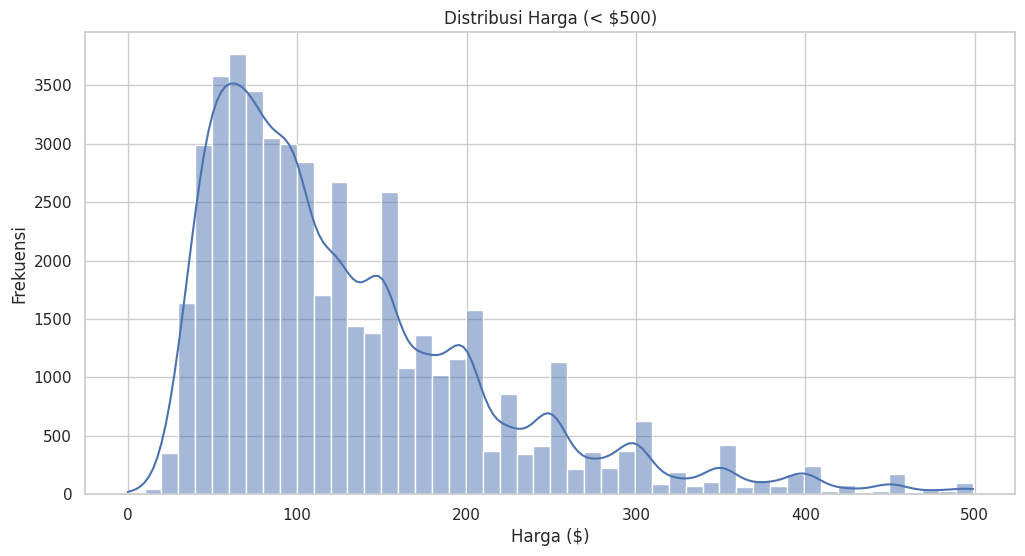

In [ ]:
# ========================
# 5. ANALISIS TIAP KOLOM
# ========================

# Nama kolom
print("Kolom-kolom:", df.columns.tolist())

# Kolom harga
print("\nStatistik harga:")
print("Min:", df['price'].min())
print("Max:", df['price'].max())
print("Mean:", df['price'].mean())
print("Median:", df['price'].median())
print("Std:", df['price'].std())

# Distribusi harga (tanpa outlier)
df_filtered = df[df['price'] < 500]  # Menghindari outlier

sns.histplot(df_filtered['price'], bins=50, kde=True)
plt.title('Distribusi Harga (< $500)')
plt.xlabel('Harga ($)')
plt.ylabel('Frekuensi')
plt.show()


## Visualisasi Data

Penjelasan:

Data divisualisasikan agar pola lebih mudah dipahami. Beberapa visual yang dibuat:

- Bar chart jumlah listing per wilayah

- Boxplot harga untuk melihat outlier

- Histogram distribusi harga

- Heatmap korelasi antar variabel numerik

- Scatter plot untuk menunjukkan lokasi listing di peta kota

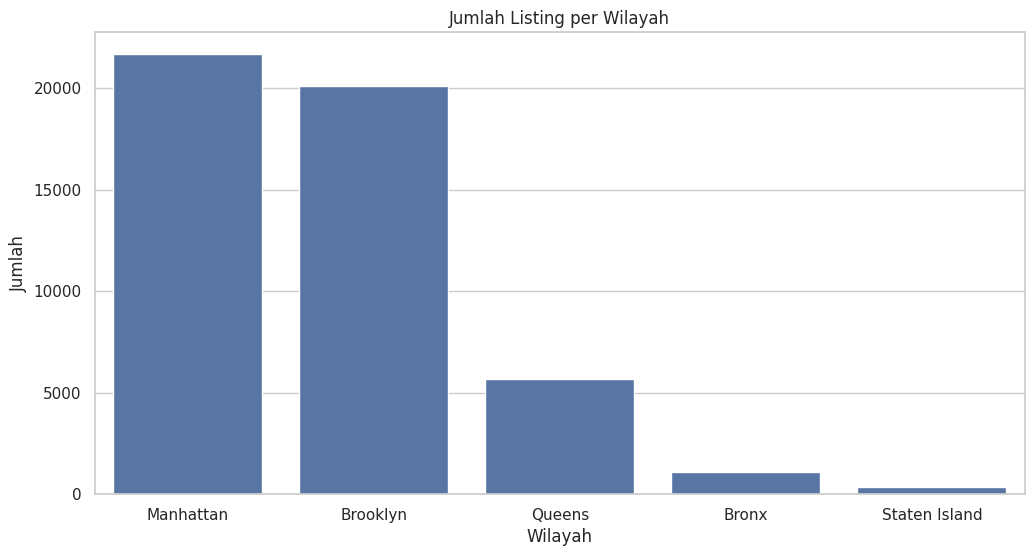

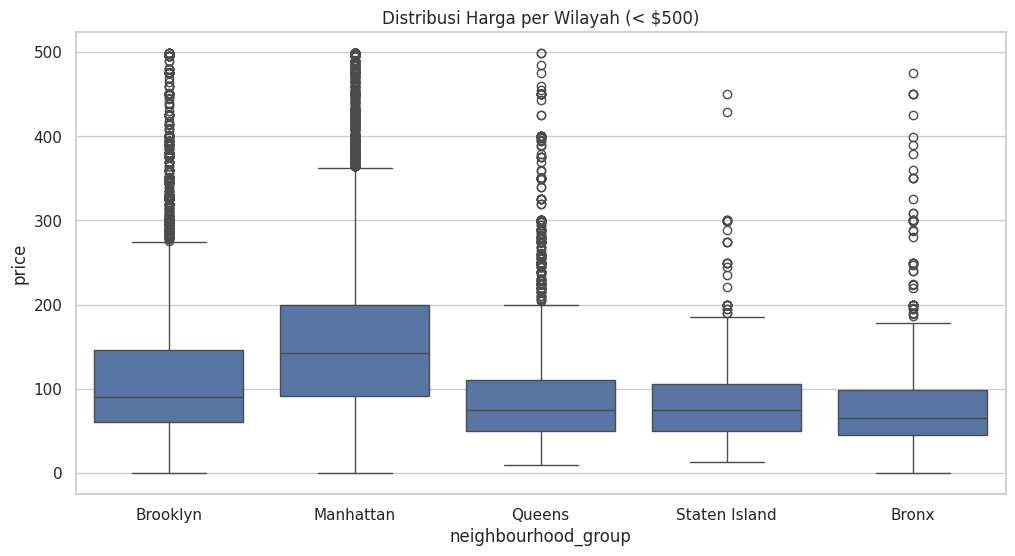

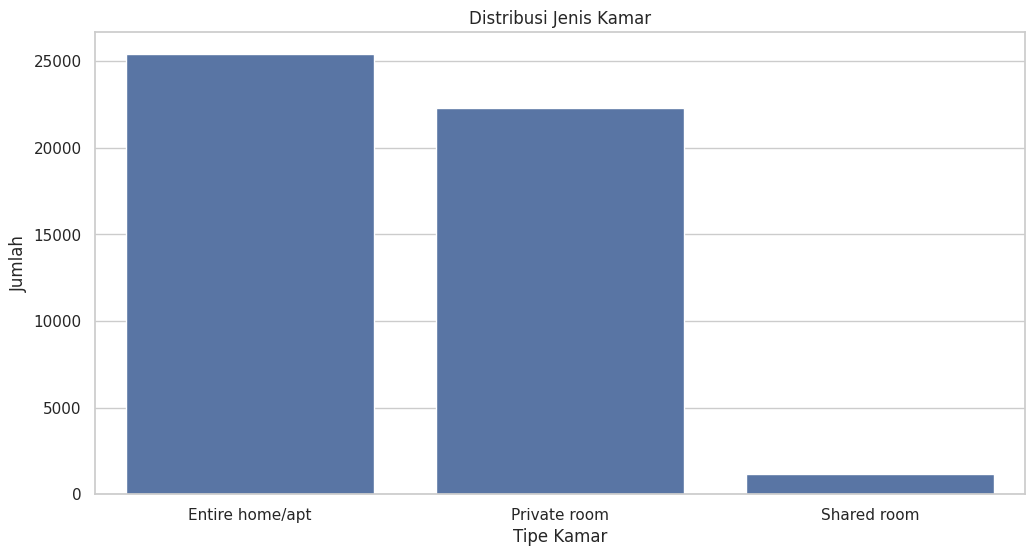

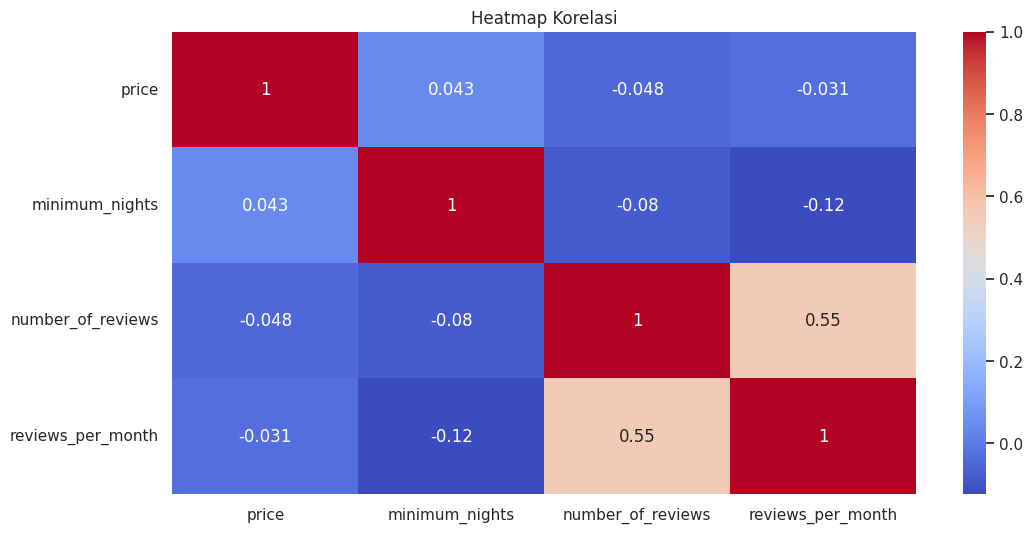

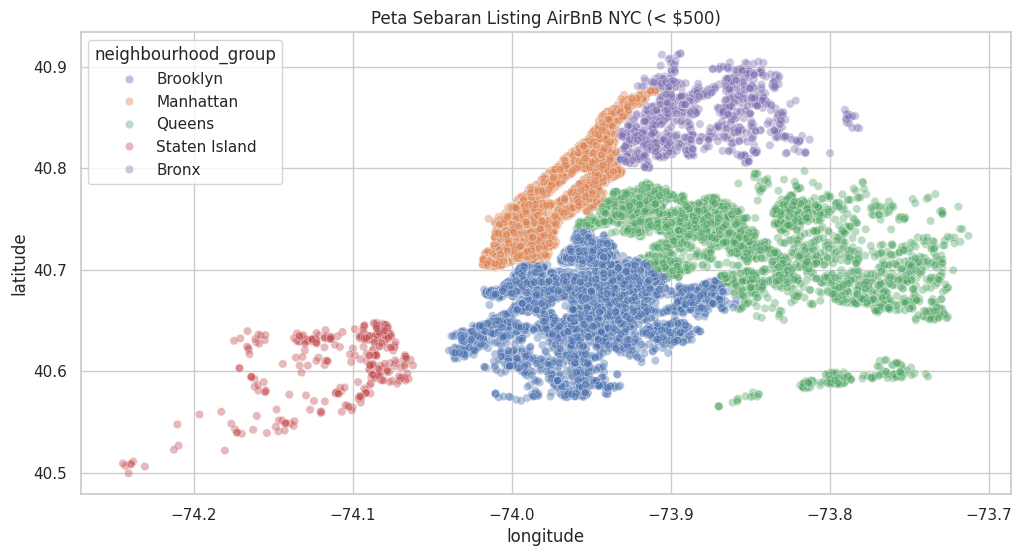

In [ ]:
# ========================
# 6. VISUALISASI
# ========================

# a. Jumlah listing berdasarkan wilayah
sns.countplot(data=df, x='neighbourhood_group', order=df['neighbourhood_group'].value_counts().index)
plt.title('Jumlah Listing per Wilayah')
plt.xlabel('Wilayah')
plt.ylabel('Jumlah')
plt.show()

# b. Boxplot harga per wilayah
df_price_filtered = df[df['price'] < 500]
sns.boxplot(data=df_price_filtered, x='neighbourhood_group', y='price')
plt.title('Distribusi Harga per Wilayah (< $500)')
plt.show()

# c. Jenis kamar
sns.countplot(data=df, x='room_type', order=df['room_type'].value_counts().index)
plt.title('Distribusi Jenis Kamar')
plt.xlabel('Tipe Kamar')
plt.ylabel('Jumlah')
plt.show()

# d. Korelasi antar variabel numerik
corr = df[['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Heatmap Korelasi')
plt.show()

# e. Lokasi geografis
sns.scatterplot(data=df[df['price'] < 500], x='longitude', y='latitude', hue='neighbourhood_group', alpha=0.4)
plt.title('Peta Sebaran Listing AirBnB NYC (< $500)')
plt.show()


## Insight

Penjelasan:

Berikut ini saya tampilkan beberapa insight utama dari data AirBnB New York City yang telah dianalisis:

- Wilayah dan jenis kamar paling populer

- Rata-rata harga dan penyebarannya

In [ ]:
# ===========
# 7. INSIGHT
# ===========

print("Beberapa insight yang ditemukan:")
print("- Wilayah dengan listing terbanyak adalah:", df['neighbourhood_group'].value_counts().idxmax())
print("- Harga rata-rata listing adalah:", round(df['price'].mean(), 2))
print("- Jenis kamar paling umum:", df['room_type'].value_counts().idxmax())
print("- Sebagian besar listing berlokasi di Manhattan dan Brooklyn.")
print("- Terdapat outlier pada kolom harga (> $500) yang dapat mempengaruhi analisis.")


Beberapa insight yang ditemukan:
- Wilayah dengan listing terbanyak adalah: Manhattan
- Harga rata-rata listing adalah: 152.72
- Jenis kamar paling umum: Entire home/apt
- Sebagian besar listing berlokasi di Manhattan dan Brooklyn.
- Terdapat outlier pada kolom harga (> $500) yang dapat mempengaruhi analisis.
